In [53]:
from pathlib import Path
import numpy as np
import xarray as xr
import xesmf as xe

from load_cmip_esgf import CMIPESGFLoader, data_dict_nybtes, align_dicts
import xclimate as xclim

import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# %load_ext autoreload
# %autoreload 2

In [54]:
# client_cluster = xclim.create_dask_cluster(
#     account="UWAS0155",
#     nworkers=4,
#     nmem="32GB",
#     walltime="01:00:00",
# )

In [55]:
CATALOG_ROOT = Path("/glade/campaign/univ/uwas0155/catalogs")
TIME_SLICE = slice("1950-01", None)

loader_cmip = CMIPESGFLoader(CATALOG_ROOT / "cmip6.csv")
loader_regrid = CMIPESGFLoader(CATALOG_ROOT / "cmip6_regridded.csv")
loader_cesm = CMIPESGFLoader(CATALOG_ROOT / "cmip_ncar_mon_catalog.csv")

In [56]:
dd_cmip = loader_cmip.load_data(
    variables=["evspsbl", "pr", "rsds", "rlds"],
    experiment_id="historical",
    source_id=None,
    omit_source_id=["EC-Earth3", "EC-Earth3-AerChem", "EC-Earth3-ESM-1", "EC-Earth3-HR", "EC-Earth3-Veg", "EC-Earth3-Veg-LR"],
    member_id="top",
    time_slice=TIME_SLICE,
    parallel=True,
)

number of models with areacella and sftlf: 44
only selecting top member_id
=== ACCESS-CM2 ===
  evspsbl      n=1     ✅r1i1p1f1 
  pr           n=1     ✅r1i1p1f1 
  rsds         n=1     ✅r1i1p1f1 
  rlds         n=1     ✅r1i1p1f1 
=== ACCESS-ESM1-5 ===
  evspsbl      n=1     ✅r1i1p1f1 
  pr           n=1     ✅r1i1p1f1 
  rsds         n=1     ✅r1i1p1f1 
  rlds         n=1     ✅r1i1p1f1 
=== AWI-CM-1-1-MR ===
  evspsbl      n=1     ✅r1i1p1f1 
  pr           n=1     ✅r1i1p1f1 
  rsds         n=1     ✅r1i1p1f1 
  rlds         n=1     ✅r1i1p1f1 
=== AWI-ESM-1-1-LR ===
  evspsbl      n=1     ✅r1i1p1f1 
  pr           n=1     ✅r1i1p1f1 
  rsds         n=1     ✅r1i1p1f1 
  rlds         n=1     ✅r1i1p1f1 
=== AWI-ESM-1-REcoM ===
  evspsbl      n=1     ✅r1i1p1f1 
  pr           n=1     ✅r1i1p1f1 
  rsds         n=1     ✅r1i1p1f1 
  rlds         n=1     ✅r1i1p1f1 
=== CMCC-CM2-SR5 ===
  evspsbl      n=1     ✅r1i1p1f1 
  pr           n=1     ✅r1i1p1f1 
  rsds         n=1     ✅r1i1p1f1 
  rlds      

In [57]:
dd_cmip_grid = loader_cmip.load_data(
    variables=["areacella", "sftlf"],
    experiment_id="historical",
    source_id=None,
    omit_source_id=["EC-Earth3", "EC-Earth3-AerChem", "EC-Earth3-ESM-1", "EC-Earth3-HR", "EC-Earth3-Veg", "EC-Earth3-Veg-LR"],
    member_id="top",
    time_slice=TIME_SLICE,
    parallel=True,
)

number of models with areacella and sftlf: 44
only selecting top member_id
=== ACCESS-CM2 ===
  areacella    n=1     ✅r1i1p1f1 
  sftlf        n=1     ✅r1i1p1f1 
=== ACCESS-ESM1-5 ===
  areacella    n=1     ✅r1i1p1f1 
  sftlf        n=1     ✅r1i1p1f1 
=== AWI-CM-1-1-MR ===
  areacella    n=1     ✅r1i1p1f1 
  sftlf        n=1     ✅r1i1p1f1 
=== AWI-ESM-1-1-LR ===
  areacella    n=1     ✅r1i1p1f1 
  sftlf        n=1     ✅r1i1p1f1 
=== AWI-ESM-1-REcoM ===
  areacella    n=1     ✅r1i1p1f1 
  sftlf        n=1     ✅r1i1p1f1 
=== CMCC-CM2-SR5 ===
  areacella    n=1     ✅r1i1p1f1 
  sftlf        n=1     ✅r1i1p1f1 
=== CMCC-ESM2 ===
  areacella    n=1     ✅r1i1p1f1 
  sftlf        n=1     ✅r1i1p1f1 
=== CNRM-CM6-1 ===
  areacella    n=1     ✅r2i1p1f2 
  sftlf        n=1     ✅r2i1p1f2 
=== CNRM-CM6-1-HR ===
  areacella    n=1     ✅r1i1p1f2 
  sftlf        n=1     ✅r1i1p1f2 
=== CNRM-ESM2-1 ===
  areacella    n=1     ✅r2i1p1f2 
  sftlf        n=1     ✅r2i1p1f2 
=== CanESM5 ===
  areacella    n=1 

In [58]:
data_dict_nybtes(dd_cmip);

total: 18.822 GB
ACCESS-CM2          : 0.321 GB
ACCESS-ESM1-5       : 0.324 GB
AWI-CM-1-1-MR       : 0.857 GB
AWI-ESM-1-1-LR      : 0.214 GB
AWI-ESM-1-REcoM     : 0.214 GB
CMCC-CM2-SR5        : 0.643 GB
CMCC-ESM2           : 0.643 GB
CNRM-CM6-1          : 0.381 GB
CNRM-CM6-1-HR       : 3.013 GB
CNRM-ESM2-1         : 0.381 GB
CanESM5             : 0.095 GB
CanESM5-1           : 0.095 GB
CanESM5-CanOE       : 0.095 GB
E3SM-1-0            : 0.718 GB
E3SM-1-1            : 0.753 GB
E3SM-1-1-ECA        : 0.753 GB
E3SM-2-0            : 0.710 GB
E3SM-2-0-NARRM      : 0.753 GB
E3SM-2-1            : 0.753 GB
FGOALS-g3           : 0.173 GB
GFDL-ESM4           : 0.603 GB
GISS-E3-G           : 0.603 GB
ICON-ESM-LR         : 0.000 GB
INM-CM4-8           : 0.251 GB
INM-CM5-0           : 0.251 GB
IPSL-CM6A-LR        : 0.239 GB
MIROC-ES2H          : 0.381 GB
MIROC-ES2L          : 0.095 GB
MIROC6              : 0.381 GB
MPI-ESM-1-2-HAM     : 0.214 GB
MPI-ESM1-2-HR       : 0.857 GB
MPI-ESM1-2-LR       : 

In [59]:
data_dict_nybtes(dd_cmip_grid);

total: 0.012 GB
ACCESS-CM2          : 0.000 GB
ACCESS-ESM1-5       : 0.000 GB
AWI-CM-1-1-MR       : 0.001 GB
AWI-ESM-1-1-LR      : 0.000 GB
AWI-ESM-1-REcoM     : 0.000 GB
CMCC-CM2-SR5        : 0.000 GB
CMCC-ESM2           : 0.000 GB
CNRM-CM6-1          : 0.000 GB
CNRM-CM6-1-HR       : 0.002 GB
CNRM-ESM2-1         : 0.000 GB
CanESM5             : 0.000 GB
CanESM5-1           : 0.000 GB
CanESM5-CanOE       : 0.000 GB
E3SM-1-0            : 0.000 GB
E3SM-1-1            : 0.000 GB
E3SM-1-1-ECA        : 0.000 GB
E3SM-2-0            : 0.000 GB
E3SM-2-0-NARRM      : 0.000 GB
E3SM-2-1            : 0.000 GB
FGOALS-g3           : 0.000 GB
GFDL-ESM4           : 0.000 GB
GISS-E3-G           : 0.000 GB
ICON-ESM-LR         : 0.000 GB
INM-CM4-8           : 0.000 GB
INM-CM5-0           : 0.000 GB
IPSL-CM6A-LR        : 0.000 GB
MIROC-ES2H          : 0.000 GB
MIROC-ES2L          : 0.000 GB
MIROC6              : 0.000 GB
MPI-ESM-1-2-HAM     : 0.000 GB
MPI-ESM1-2-HR       : 0.001 GB
MPI-ESM1-2-LR       : 0

In [60]:
for i, (sid, vardict) in enumerate(dd_cmip_grid.items()):
    if len(vardict.keys()) > 0:
        dd_cmip_grid[sid]["lf"] = dd_cmip_grid[sid]["sftlf"].reindex_like(dd_cmip_grid[sid]["areacella"], method="nearest", tolerance=1e-3)
        dd_cmip_grid[sid]["la"] = dd_cmip_grid[sid]["areacella"] * dd_cmip_grid[sid]["lf"]

In [61]:
print(f"number of CMIP models: {len(dd_cmip.keys())}")
print(f"number of CMIP models: {len(dd_cmip_grid.keys())}")

number of CMIP models: 38
number of CMIP models: 38


In [62]:
dd_cmip_aligned, dd_cmip_grid_aligned = align_dicts(dd_cmip, dd_cmip_grid)

In [63]:
print(f"number of CMIP models: {len(dd_cmip_aligned.keys())}")
print(f"number of CMIP models: {len(dd_cmip_grid_aligned.keys())}")

number of CMIP models: 37
number of CMIP models: 37


ACCESS-CM2          : (1, 144, 192) (1, 780, 144, 192)
ACCESS-ESM1-5       : (1, 145, 192) (1, 780, 145, 192)
AWI-CM-1-1-MR       : (1, 192, 384) (1, 780, 192, 384)
AWI-ESM-1-1-LR      : (1, 96, 192) (1, 780, 96, 192)
AWI-ESM-1-REcoM     : (1, 96, 192) (1, 780, 96, 192)
CMCC-CM2-SR5        : (1, 192, 288) (1, 780, 192, 288)
CMCC-ESM2           : (1, 192, 288) (1, 780, 192, 288)
CNRM-CM6-1          : (1, 128, 256) (1, 780, 128, 256)
CNRM-CM6-1-HR       : (1, 360, 720) (1, 780, 360, 720)
CNRM-ESM2-1         : (1, 128, 256) (1, 780, 128, 256)
CanESM5             : (1, 64, 128) (1, 780, 64, 128)
CanESM5-1           : (1, 64, 128) (1, 780, 64, 128)
CanESM5-CanOE       : (1, 64, 128) (1, 780, 64, 128)
E3SM-1-0            : (1, 180, 360) (1, 780, 180, 360)
E3SM-1-1            : (1, 180, 360) (1, 780, 180, 360)
E3SM-1-1-ECA        : (1, 180, 360) (1, 780, 180, 360)
E3SM-2-0            : (1, 180, 360) (1, 780, 180, 360)
E3SM-2-0-NARRM      : (1, 180, 360) (1, 780, 180, 360)
E3SM-2-1            

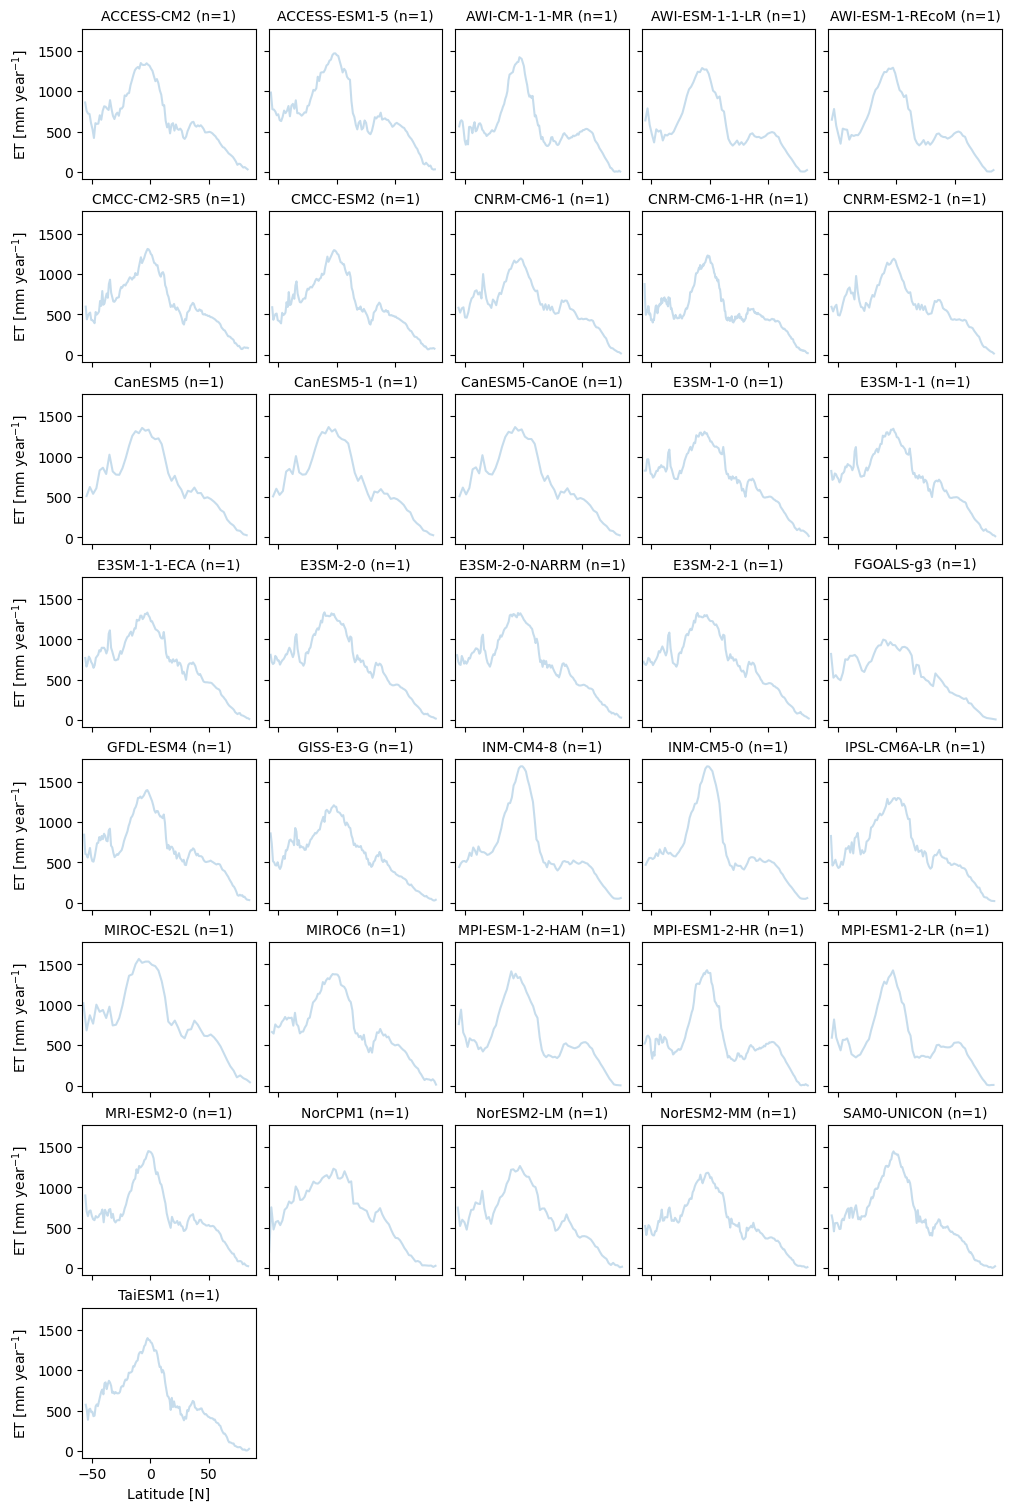

In [ ]:
v = "evspsbl"
cf = 86400 * 365
cs = 0
time_bnds = slice("1995-01", "2014-12")
lat_bnds = slice(-60, 90)
lf_thresh = 0.50

nrows = 8
ncols = 5

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(10, 15), layout="constrained", sharex=True, sharey=True)
axs = axes.ravel()

nremove = 0
for i, (sid, vardict) in enumerate(dd_cmip_aligned.items()):
    if (v in vardict.keys()) and ("lon" in vardict[v].dims) and ("lat" in vardict[v].dims):

        lf = dd_cmip_grid[sid]["lf"].reindex_like(vardict[v], method="nearest", tolerance=1e-3)
        da = vardict[v].where(lf > lf_thresh).sel(time=time_bnds, lat=lat_bnds) * cf + cs

        print(f"{sid:20}: {dd_cmip_grid[sid]['lf'].shape} {vardict[v].shape}")
    
        if ("member" in da.dims) and (len(da.member) > 1):
            for m in da.member:
                da.sel(member=m).mean(dim=["time", "lon"]).plot(ax=axs[i-nremove], color="tab:blue", alpha=0.25, _labels=False)
            axs[i-nremove].set_title(f"{sid} (n={len(da.member):d})", fontsize=10)
        else:
            da.mean(dim=["time", "lon"]).plot(ax=axs[i-nremove], color="tab:blue", alpha=0.5, _labels=False)
            axs[i-nremove].set_title(f"{sid} (n=1)", fontsize=10)

    else:
        nremove += 1
        print(f"❌{sid:20}")

for i in range(ncols):
    axes[-1, i].set_xlabel("Latitude [N]")

for i in range(nrows):
    axes[i, 0].set_ylabel("ET [mm year$^{-1}$]")

for ax in axs:
    ax.set_xlim(lat_bnds.start, lat_bnds.stop)

extra_plots = len(axs) - len(dd_cmip_aligned.keys()) + nremove
for ax in axs[-extra_plots:]:
    ax.set_xticks([-60, -30, 0, 30, 60, 90])
    ax.remove()

ACCESS-CM2          : (1, 144, 192) (1, 780, 144, 192)
ACCESS-ESM1-5       : (1, 145, 192) (1, 780, 145, 192)
AWI-CM-1-1-MR       : (1, 192, 384) (1, 780, 192, 384)
AWI-ESM-1-1-LR      : (1, 96, 192) (1, 780, 96, 192)
AWI-ESM-1-REcoM     : (1, 96, 192) (1, 780, 96, 192)
CMCC-CM2-SR5        : (1, 192, 288) (1, 780, 192, 288)
CMCC-ESM2           : (1, 192, 288) (1, 780, 192, 288)
CNRM-CM6-1          : (1, 128, 256) (1, 780, 128, 256)
CNRM-CM6-1-HR       : (1, 360, 720) (1, 780, 360, 720)
CNRM-ESM2-1         : (1, 128, 256) (1, 780, 128, 256)
CanESM5             : (1, 64, 128) (1, 780, 64, 128)
CanESM5-1           : (1, 64, 128) (1, 780, 64, 128)
CanESM5-CanOE       : (1, 64, 128) (1, 780, 64, 128)
E3SM-1-0            : (1, 180, 360) (1, 780, 180, 360)
E3SM-1-1            : (1, 180, 360) (1, 780, 180, 360)
E3SM-1-1-ECA        : (1, 180, 360) (1, 780, 180, 360)
E3SM-2-0            : (1, 180, 360) (1, 780, 180, 360)
E3SM-2-0-NARRM      : (1, 180, 360) (1, 780, 180, 360)
E3SM-2-1            

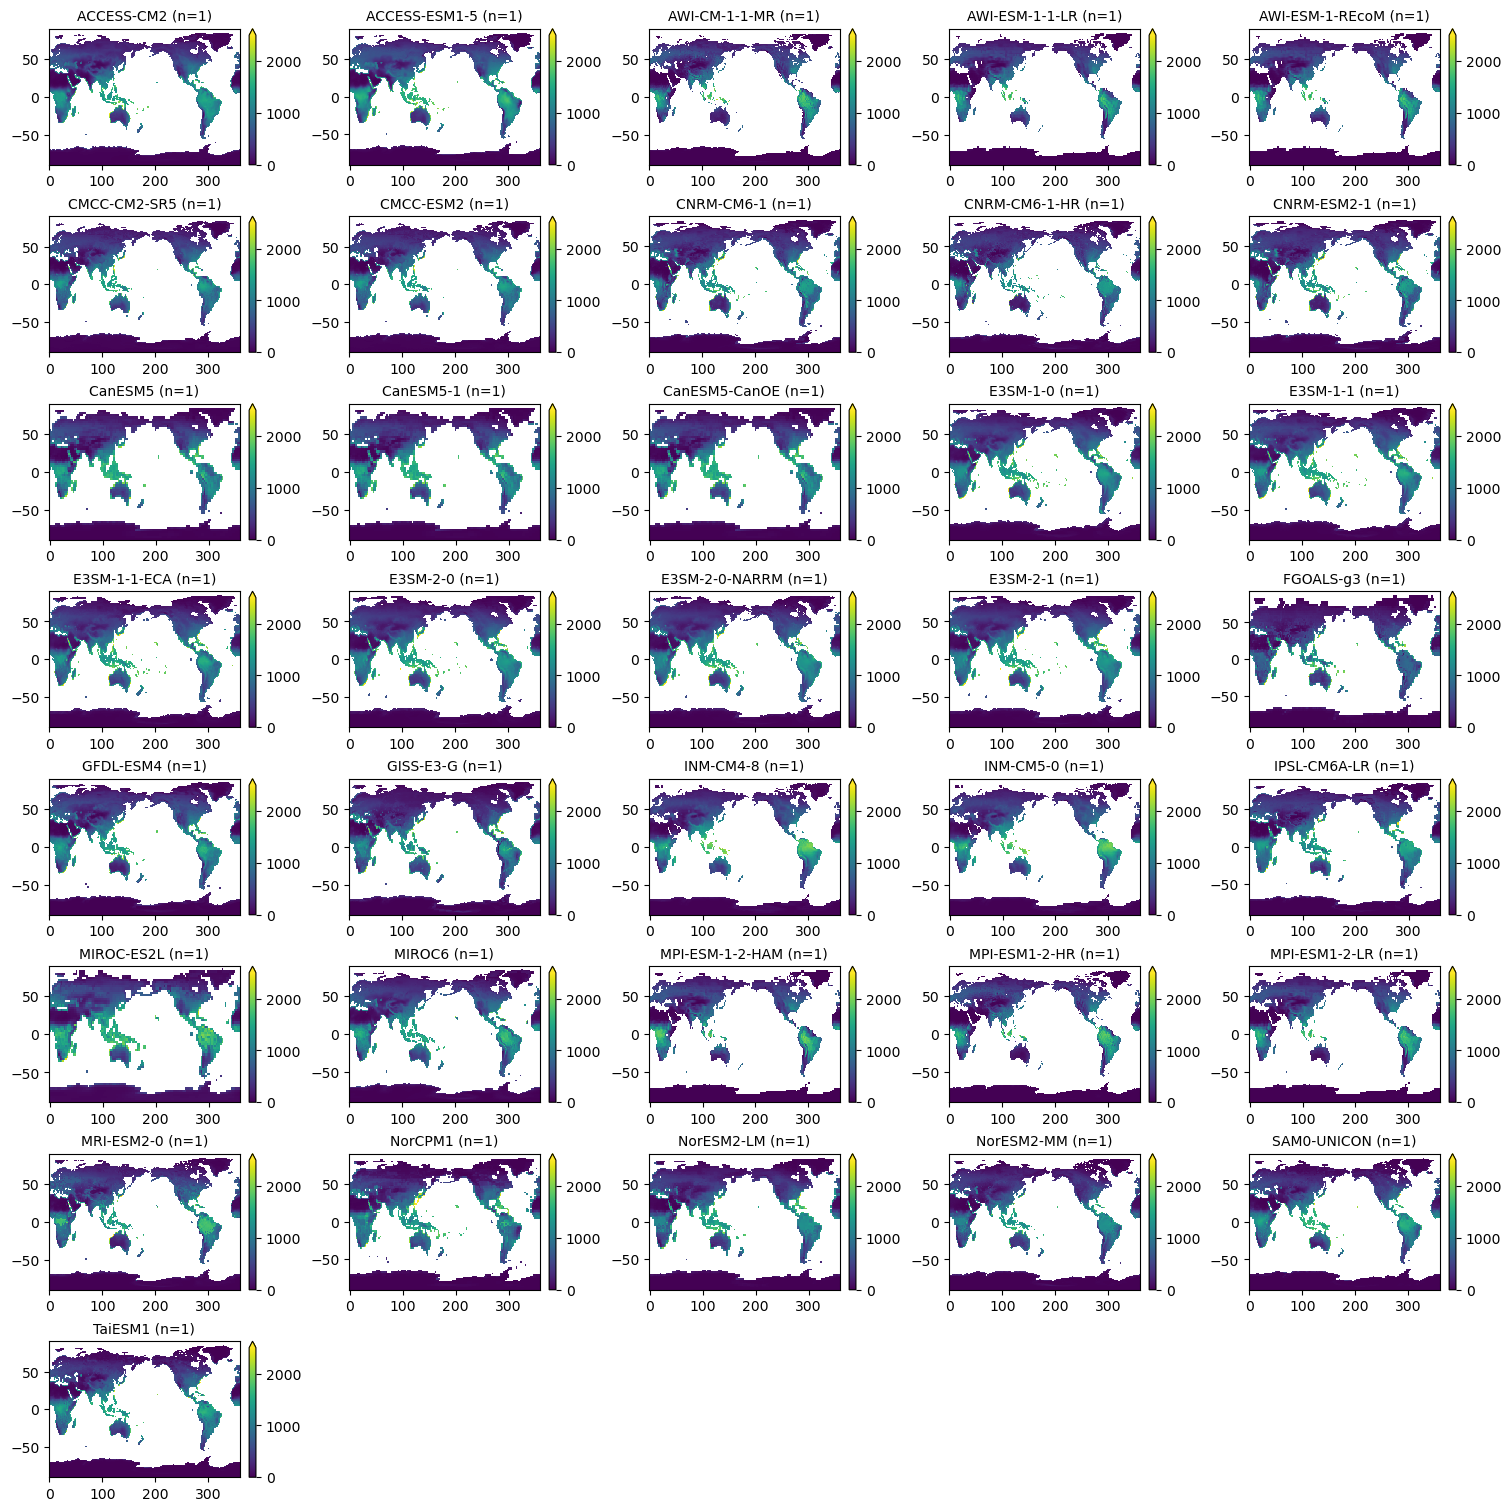

In [ ]:
v = "evspsbl"
cf = 86400 * 365
cs = 0
time_bnds = slice("1995-01", "2014-12")
lat_bnds = slice(-60, 90)
lf_thresh = 0.50

subplot_kwargs = dict(vmin=0, vmax=2500, cbar_kwargs={"extend": "max"}, add_labels=False)

nrows = 8
ncols = 5

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 15), layout="constrained")
axs = axes.ravel()

nremove = 0
for i, (sid, vardict) in enumerate(dd_cmip_aligned.items()):
    if (v in vardict.keys()) and ("lon" in vardict[v].dims) and ("lat" in vardict[v].dims):

        lf = dd_cmip_grid[sid]["lf"].reindex_like(vardict[v], method="nearest", tolerance=1e-3)
        da = vardict[v].where(lf > lf_thresh).sel(time=time_bnds, lat=lat_bnds) * cf + cs

        print(f"{sid:20}: {dd_cmip_grid[sid]['lf'].shape} {vardict[v].shape}")
    
        if ("member" in da.dims) and (len(da.member) > 1):
            for m in da.member:
                da.sel(member=m).mean(dim=["time"]).plot(ax=axs[i-nremove], **subplot_kwargs)
            axs[i-nremove].set_title(f"{sid} (n={len(da.member):d})", fontsize=10)
        else:
            da.mean(dim=["time"]).plot(ax=axs[i-nremove], **subplot_kwargs)
            axs[i-nremove].set_title(f"{sid} (n=1)", fontsize=10)

    else:
        nremove += 1
        print(f"❌{sid:20}")

extra_plots = len(axs) - len(dd_cmip_aligned.keys()) + nremove
for ax in axs[-extra_plots:]:
    ax.remove()

In [ ]:
sid = "INM-CM4-8"
v = "evspsbl"

lf = dd_cmip_grid[sid]["lf"].reindex_like(dd_cmip[sid][v], method="nearest", tolerance=1e-3)
da = dd_cmip[sid][v].where(lf > lf_thresh).sel(time=time_bnds, lat=lat_bnds) * cf + cs

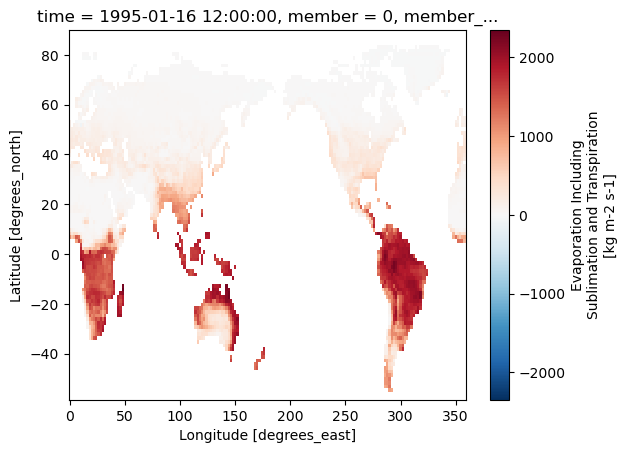

In [41]:
da.isel(time=0).plot()